In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [3]:
path = "data/pollution_cleaneddata.csv"
data = pd.read_csv(path)
data.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


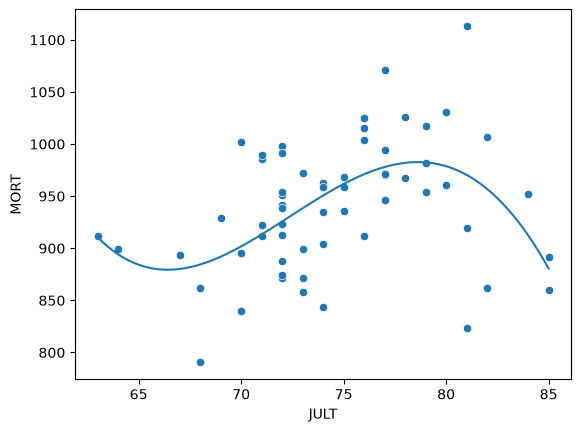

In [4]:
mortality = data["MORT"]
july = data["JULT"]

degree = 4

fit = np.polyfit(july, mortality, degree)
polynomial = np.poly1d(fit)

sb.scatterplot(x = july, y = mortality)
fit_test_x = np.linspace(min(july), max(july), 100)
sb.lineplot(x = fit_test_x, y = polynomial(fit_test_x))
plt.show()

## Split the data

In [5]:
seed = 0

def split(seed):
    training_mort, testing_mort = train_test_split(
        mortality,
        test_size=0.5,
        random_state=seed
    )

    training_july, testing_july = train_test_split(
        july,
        test_size=0.5,
        random_state=seed
    )
    return training_july, training_mort, testing_july, testing_mort

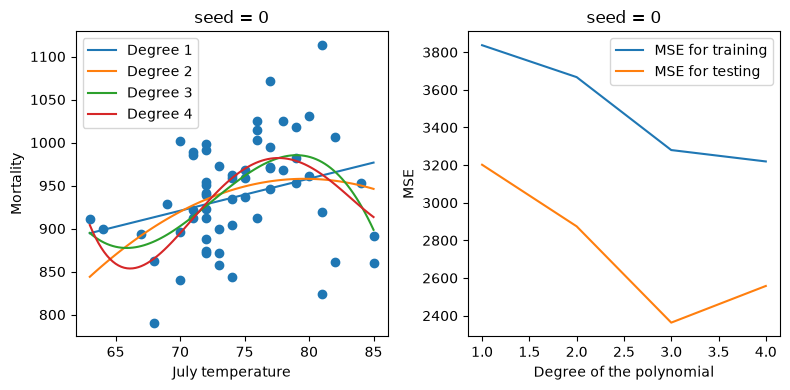

In [6]:
def plot(ax1, ax2, seed):
    degrees = [1,2,3,4]
    train_mse = []
    test_mse = []

    training_july, training_mort, testing_july, testing_mort = split(seed)

    for degree in degrees:
        fit = np.polyfit(
            training_july, training_mort, degree
        )
        polynomial = np.poly1d(fit)
        
        y_pred_train = polynomial(training_july)
        mse_train = np.mean((training_mort - y_pred_train)**2)
        
        y_pred_test = polynomial(testing_july)
        mse_test = np.mean((testing_mort - y_pred_test)**2)

        train_mse.append(mse_train)
        test_mse.append(mse_test)
        
        fit_test_x = np.linspace(min(july), max(july), 100)
        ax1.plot(fit_test_x, polynomial(fit_test_x), label = f"Degree {degree}")
        
    ax1.scatter(july, mortality)
    ax1.set_xlabel("July temperature")
    ax1.set_ylabel("Mortality")
    ax1.legend()
    ax1.set_title(f"seed = {seed}")


    ax2.plot(degrees, train_mse, label = "MSE for training")
    ax2.plot(degrees, test_mse, label = "MSE for testing")
    ax2.set_xlabel("Degree of the polynomial")
    ax2.set_ylabel("MSE")
    ax2.legend()
    ax2.set_title(f"seed = {seed}")


fig, ax = plt.subplots(1,2, figsize = (8,4))
plot(ax[0], ax[1], 0)

plt.tight_layout()
plt.show()

The optimal degree for generalization seems to the 3.

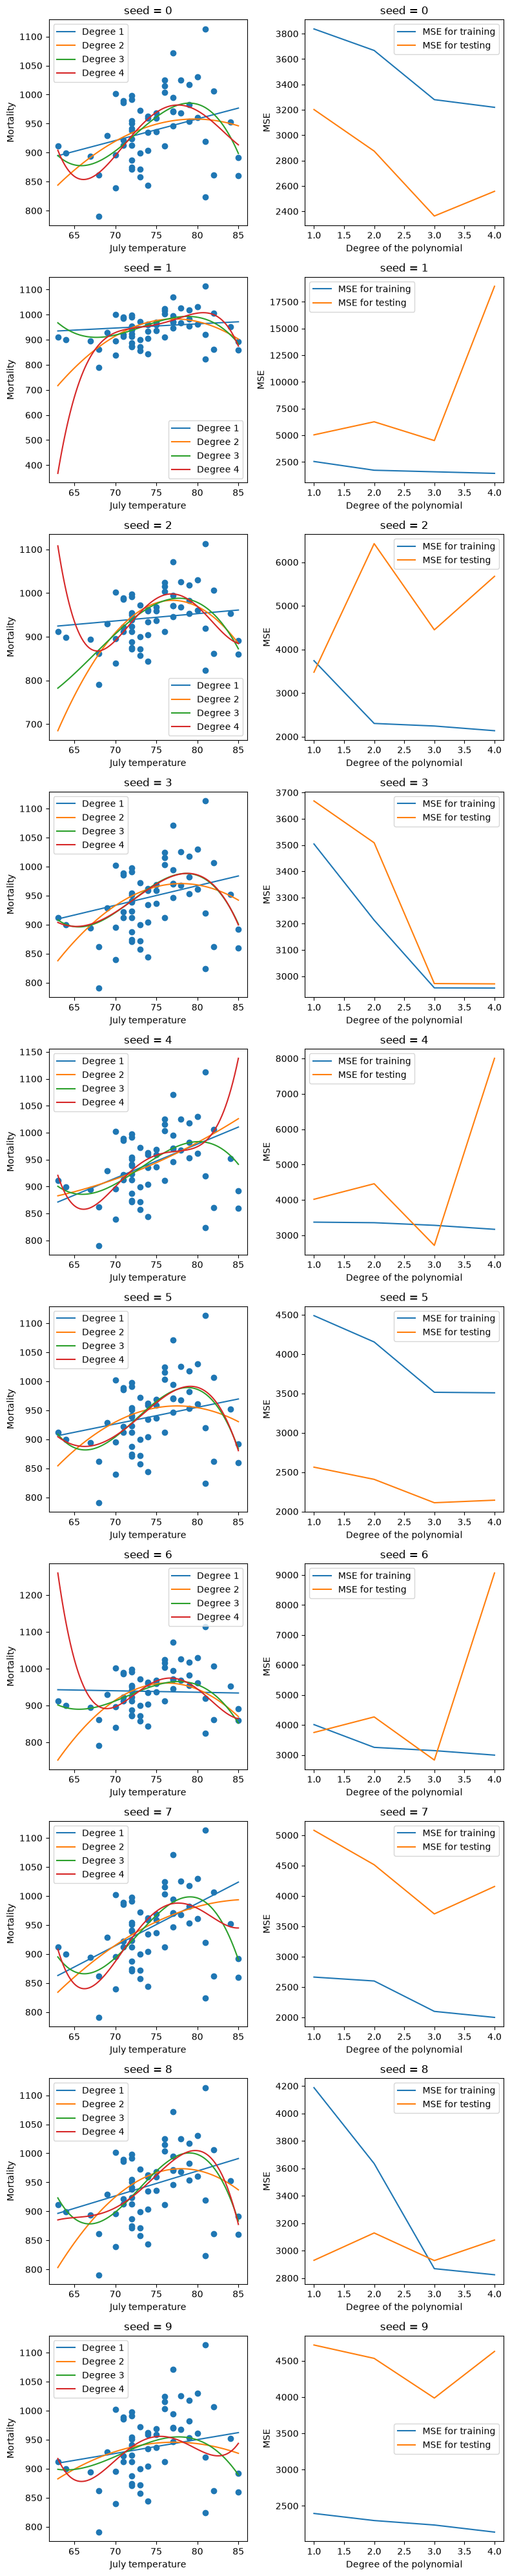

In [7]:
fig, ax = plt.subplots(10,2, figsize = (8,40))
for seed in [0,1,2,3,4,5,6,7,8,9]:
    plot(ax[seed,0], ax[seed,1], seed)

plt.tight_layout()
plt.show()

For other seeds, we still see that the optimal degree for generalization seems to be 3. 

Seed 0: mean MSE = 3105.12, mean model variance = 1375.79
Seed 1: mean MSE = 3476.64, mean model variance = 1415.05
Seed 2: mean MSE = 3476.04, mean model variance = 1912.63
Seed 3: mean MSE = 3313.19, mean model variance = 1520.87
Seed 4: mean MSE = 3122.86, mean model variance = 1341.24


Seed 5: mean MSE = 3016.23, mean model variance = 1429.61
Seed 6: mean MSE = 3775.02, mean model variance = 2025.82
Seed 7: mean MSE = 2974.84, mean model variance = 1364.74
Seed 8: mean MSE = 2891.85, mean model variance = 1372.37
Seed 9: mean MSE = 3568.33, mean model variance = 1638.13


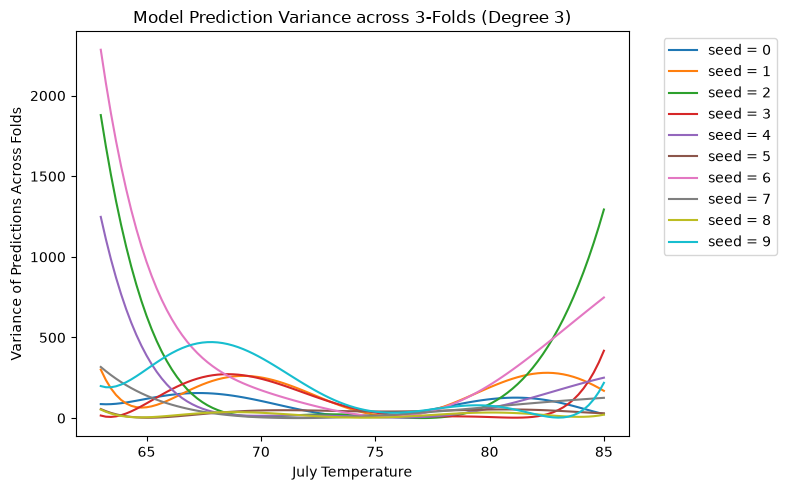

In [18]:
degree = 3
K = 3

# Define a single, fixed temperature grid to evaluate all models on
eval_temps = np.linspace(july.min(), july.max(), 100)

def K_fold(seed, degree, K=3):
    kfold = KFold(n_splits=K, shuffle=True, random_state=seed)
    
    mse = []
    grid_preds = []
    
    for train_idx, test_idx in kfold.split(july):
        training_july = july.iloc[train_idx]
        testing_july = july.iloc[test_idx]
        
        training_mort = mortality.iloc[train_idx]
        testing_mort = mortality.iloc[test_idx]
        
        # Fit polynomial on training fold
        fit = np.polyfit(training_july, training_mort, degree)
        polynomial = np.poly1d(fit)
        
        # Calculate MSE on held-out test fold
        test_predictions = polynomial(testing_july)
        fold_mse = np.mean((testing_mort - test_predictions)**2)
        mse.append(fold_mse)
        
        # Predict on the common temperature grid for variance analysis
        grid_preds.append(polynomial(eval_temps))
        
    return np.array(mse), np.array(grid_preds)

# Plotting
plt.figure(figsize=(8, 5))

for seed in range(10):
    mse, grid_preds = K_fold(seed, degree=degree, K=K)
    
    # Calculate variance across the K folds for each temperature point
    variance_across_folds = np.var(grid_preds, axis=0)
    
    # Calculate overall prediction variance across all folds/grid points
    total_variance = np.var(grid_preds)
    
    print(
        f"Seed {seed}: "
        f"mean MSE = {np.mean(mse):.2f}, "
        f"mean model variance = {total_variance:.2f}"
    )
    
    plt.plot(eval_temps, variance_across_folds, label=f"seed = {seed}")

plt.xlabel("July Temperature")
plt.ylabel("Variance of Predictions Across Folds")
plt.title(f"Model Prediction Variance across {K}-Folds (Degree {degree})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Bootstrap

In [22]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson

# 1. Load Data
path = "data/bird_count.csv"
file = pd.read_csv(path)

Years = file["yr"].values
counts = file["count"].values

max_year = Years.max()
Years_scaled = Years / max_year

In [23]:
# 2. Log-likelihood function for Poisson regression
def log_likely(beta, x, y):
    beta_0, beta_1 = beta
    eta = beta_0 + beta_1 * x
    # Poisson log-likelihood sum: y * eta - exp(eta)
    return np.sum(-np.exp(eta) + y * eta)

# Function to fit Poisson MLE and return unscaled slope parameter
def fit_poisson_slope(x_scaled, y):
    # Initial guess [1, 1] matching original code
    init_beta = [1.0, 1.0]
    
    # Minimize negative log-likelihood
    res = minimize(lambda b: -log_likely(b, x_scaled, y), init_beta)
    
    # Extract scaled beta_1 and convert to unscaled slope (per actual year)
    beta_1_scaled = res.x[1]
    beta_1_unscaled = beta_1_scaled / max_year
    return beta_1_unscaled

# Fit model on original full dataset
mle_unscaled_slope = fit_poisson_slope(Years_scaled, counts)
print(f"Full Data MLE Estimate of Slope (unscaled): {mle_unscaled_slope:.6f}")

Full Data MLE Estimate of Slope (unscaled): -0.032444


In [36]:

# 3. Bootstrap Estimation
B = 10000
np.random.seed(42)

bootstrap_slopes = []
n_samples = len(file)

for _ in range(B):
    # Resample rows with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    boot_x_scaled = Years_scaled[boot_indices]
    boot_y = counts[boot_indices]
    
    # Fit Poisson model on bootstrap sample
    boot_slope = fit_poisson_slope(boot_x_scaled, boot_y)
    bootstrap_slopes.append(boot_slope)

# Standard Error = Standard deviation of bootstrap sample slopes
bootstrap_se = np.std(bootstrap_slopes, ddof=1)

print(f"Bootstrap Standard Error of Slope: {bootstrap_se:.6f}")

Bootstrap Standard Error of Slope: 0.034546


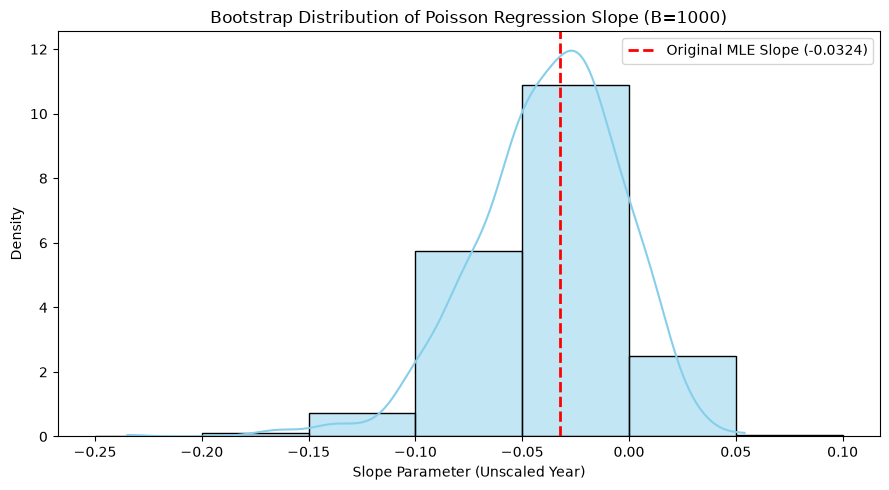

In [35]:
# Histogram
plt.figure(figsize=(9, 5))

# Plot histogram with KDE curve
sb.histplot(bootstrap_slopes, bins=np.arange(-0.25,0.15,0.05), kde=True, color="skyblue", edgecolor="black", stat="density")

# Add line for Original MLE estimate
plt.axvline(
    mle_unscaled_slope, 
    color="red", 
    linestyle="--", 
    linewidth=2, 
    label=f"Original MLE Slope ({mle_unscaled_slope:.4f})"
)

plt.title(f"Bootstrap Distribution of Poisson Regression Slope (B={B})")
plt.xlabel("Slope Parameter (Unscaled Year)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()